# Spiking Handwritten Digits Classifier using `superneuroabm`

This tutorial demonstrates how to classify handwritten digits (sklearn 8×8 digits, 10 classes) using **SuperNeuroABM**, a GPU-accelerated agent-based spiking neural network simulator.

We build a two-layer feedforward SNN with semi-supervised STDP learning:
- **64 input LIF neurons** (one per pixel)
- **640 STDP synapses** (fully connected, bounded to [0, 1])
- **10 output LIF neurons** (one per class)

During training, a target synapse forces the correct output neuron to fire,
so STDP learns which input pixels correlate with each class.
During inference, only the learned weights drive the outputs.

## Imports

In [120]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets
import sklearn.model_selection
import sklearn.metrics
from math import ceil
from pathlib import Path
from tqdm import tqdm

from superneuroabm.model import NeuromorphicModel

## Load and Explore the Digits Dataset

In [121]:
digits = sklearn.datasets.load_digits(n_class=10)
print(f"Data shape: {digits.data.shape}")
print(f"Target shape: {digits.target.shape}")
print(f"Classes: {np.unique(digits.target)}")
print(f"Pixel range: [{digits.data.min()}, {digits.data.max()}]")

Data shape: (1797, 64)
Target shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]
Pixel range: [0.0, 16.0]


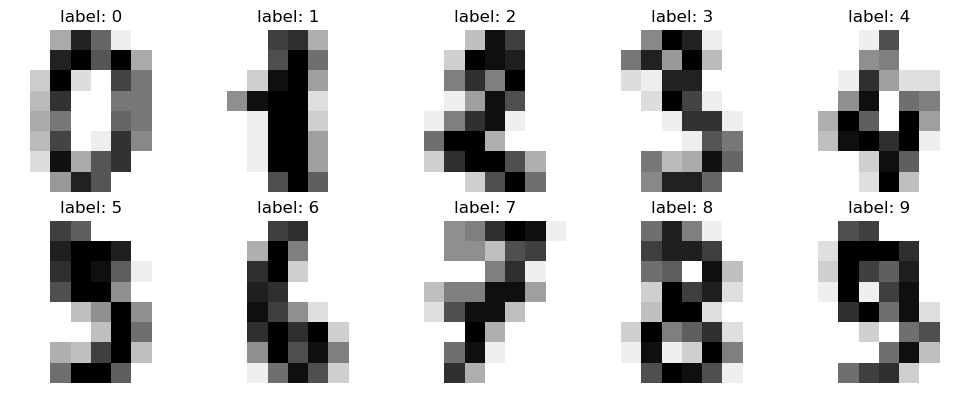

In [122]:
# Show example digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.flatten(), digits.images[:10], digits.target[:10]):
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"label: {label}")
    ax.set_axis_off()
plt.tight_layout()
plt.show()

In [123]:
# 50/50 train/test split (shuffle for interleaved class presentations — critical for STDP LTD)
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    digits.data, digits.target, test_size=0.5, shuffle=True, random_state=42
)
n_classes = len(np.unique(digits.target))
input_size = X_train.shape[1]  # 64 pixels
print(f"Train: {len(X_train)}, Test: {len(X_test)}, Classes: {n_classes}, Input size: {input_size}")

Train: 898, Test: 899, Classes: 10, Input size: 64


## Network Architecture

We use a custom config (`digits_config.yaml`) with the built-in **memristive STDP** rule (`stdp_type=3`).

| Component | Count | Config | Purpose |
|-----------|-------|--------|---------|
| Input somas | 64 | `digits_input_config` | LIF neurons, one per pixel |
| Output somas | 10 | `digits_output_config` | LIF neurons, vthr=0 (only target can fire) |
| Input synapses | 64 | `digits_input_synapse_config` | External → input somas, weight=14, no learning |
| Target synapses | 10 | `digits_target_synapse_config` | External → output somas, weight=100, no learning |
| Learning synapses | 640 | `digits_learning_synapse_config` | Input → output, memristive STDP [0, 1] |

**Key design choices:**
- Output `vthr=0` during training: with `vrest=-60`, only the target synapse (weight=100) can fire outputs.
  Learning synapses start at weight=0.1, too weak to cross the 60mV gap.
- **Memristive STDP** (`stdp_type=3`) maps weights to conductance space [Gmin, Gmax] before updating,
  applies nonlinear state-dependent switching (gamma coefficient) — low weights increase easily,
  high weights decrease easily (soft bounding). Gaussian write noise and read noise model real
  memristor device variability, producing noisier but more hardware-realistic weight updates.
- Shuffled training data ensures interleaved class presentations, which is critical for trace-based STDP:
  consecutive different-class samples keep post_trace non-zero, enabling effective LTD.
- `TARGET_OFFSET=2` aligns pre and post spikes at the same tick for maximum LTP.

In [108]:
# Create model with custom config (memristive STDP is built-in at stdp_type=3)
CONFIG_DIR = Path(".").resolve()
model = NeuromorphicModel(
    user_config=CONFIG_DIR / "digits_config.yaml",
    enable_internal_state_tracking=False,
)

In [110]:
def create_layer(model, size, config_name):
    """Create a layer of LIF somas."""
    ids = []
    for _ in range(size):
        soma_id = model.create_soma(
            breed="lif_soma",
            config_name=config_name,
        )
        ids.append(soma_id)
    return ids


def create_input_synapses(model, soma_ids, config_name):
    """Create one external-input synapse (pre=-1) per soma."""
    ids = []
    for soma_id in soma_ids:
        syn_id = model.create_synapse(
            breed="single_exp_synapse",
            pre_soma_id=-1,
            post_soma_id=soma_id,
            config_name=config_name,
        )
        ids.append(syn_id)
    return ids


def fully_connect(model, pre_ids, post_ids, config_name):
    """Create STDP-enabled synapses between all pairs."""
    syn_ids = []
    for pre_id in pre_ids:
        for post_id in post_ids:
            syn_id = model.create_synapse(
                breed="single_exp_synapse",
                pre_soma_id=pre_id,
                post_soma_id=post_id,
                config_name=config_name,
            )
            syn_ids.append(syn_id)
    return syn_ids

In [111]:
# Build the network
input_somas = create_layer(model, input_size, config_name="digits_input_config")
output_somas = create_layer(model, n_classes, config_name="digits_output_config")

input_synapses = create_input_synapses(model, input_somas, config_name="digits_input_synapse_config")
target_synapses = create_input_synapses(model, output_somas, config_name="digits_target_synapse_config")
learning_synapses = fully_connect(
    model, input_somas, output_somas,
    config_name="digits_learning_synapse_config",
)

print(f"Input somas: {len(input_somas)}")
print(f"Output somas: {len(output_somas)}")
print(f"Input synapses: {len(input_synapses)}")
print(f"Target synapses: {len(target_synapses)}")
print(f"Learning synapses: {len(learning_synapses)}")
print(f"Total agents: {len(input_somas) + len(output_somas) + len(input_synapses) + len(target_synapses) + len(learning_synapses)}")

Input somas: 64
Output somas: 10
Input synapses: 64
Target synapses: 10
Learning synapses: 640
Total agents: 788


## Training Encoding

Each training sample is presented over **5 ticks**:
- **Tick T+0**: Binary input spikes (pixel > threshold → spike 1.0)
- **Tick T+2**: Target spike forces the correct output neuron to fire
- **Ticks T+3..T+4**: STDP processes, voltages decay before next sample

**Timing chain:** Input spike at T+0 → input soma fires at T+2 → learning synapse
reads pre spike at T+3. Target spike at T+2 → output soma fires at T+3.
Pre and post align at T+3 for maximum LTP.

In [112]:
# Encoding parameters
PIXEL_THRESHOLD = 4    # binarize: pixel > threshold -> spike
TICKS_PER_SAMPLE = 5   # spacing between samples
TARGET_OFFSET = 2      # ticks after input before target fires

# Build spike lists for each synapse
input_spike_lists = {syn_id: [] for syn_id in input_synapses}
target_spike_lists = {syn_id: [] for syn_id in target_synapses}

for sample_idx, (image, label) in enumerate(zip(X_train, y_train)):
    t_base = sample_idx * TICKS_PER_SAMPLE

    # Input spikes: binary encoding
    for pixel_idx, pixel_val in enumerate(image):
        if pixel_val > PIXEL_THRESHOLD:
            input_spike_lists[input_synapses[pixel_idx]].append([t_base, 1.0])

    # Target spike: force the correct output to fire
    target_spike_lists[target_synapses[label]].append([t_base + TARGET_OFFSET, 1.0])

# Inject all spikes
for syn_id, spikes in input_spike_lists.items():
    if spikes:
        model.add_spike_list(syn_id, spikes)

for syn_id, spikes in target_spike_lists.items():
    if spikes:
        model.add_spike_list(syn_id, spikes)

total_training_ticks = len(X_train) * TICKS_PER_SAMPLE
print(f"Training samples: {len(X_train)}")
print(f"Total training ticks: {total_training_ticks}")

Training samples: 898
Total training ticks: 4490


In [113]:
# Setup and simulate training
model.setup(use_gpu=True)
model.set_recorded_somas([])  # no recording needed during training
model.simulate(ticks=total_training_ticks)

## Extract and Visualize Learned Weights

In [114]:
# Extract the 64x10 weight matrix from learning synapses
# learning_synapses is ordered: [input_0->output_0, input_0->output_1, ..., input_63->output_9]
weight_matrix = np.zeros((input_size, n_classes))
for i, syn_id in enumerate(learning_synapses):
    hp = model.get_agent_property_value(id=syn_id, property_name="hyperparameters")
    weight = hp[0]
    pre_idx = i // n_classes
    post_idx = i % n_classes
    weight_matrix[pre_idx, post_idx] = weight

print(f"Weight matrix shape: {weight_matrix.shape}")
print(f"Weight range: [{weight_matrix.min():.4f}, {weight_matrix.max():.4f}]")

Weight matrix shape: (64, 10)
Weight range: [0.0122, 1.0000]


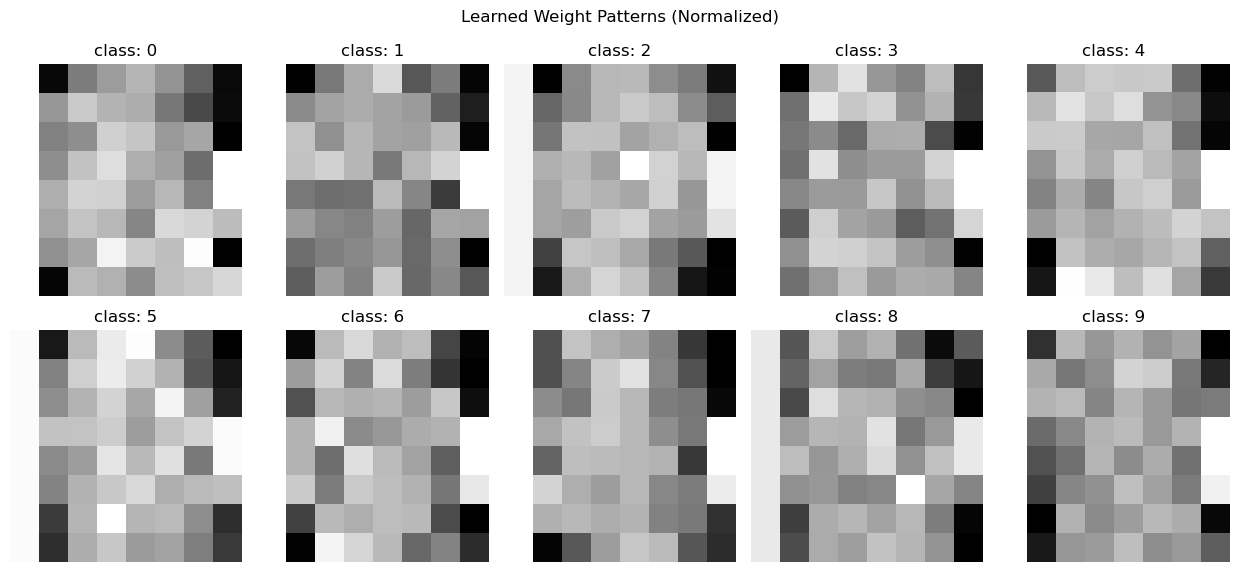

In [115]:
# Normalize weights to [0, 1]
norm_weights = weight_matrix - weight_matrix.min()
if norm_weights.max() > 0:
    norm_weights = norm_weights / norm_weights.max()

# Visualize weight patterns per class as 8x8 images
images = norm_weights.T.reshape(n_classes, 8, 8)
rows, cols = ceil(n_classes / 5), min(n_classes, 5)
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(2.5 * cols, 3 * rows))
for ax, image, cls in zip(axes.flatten(), images, range(n_classes)):
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"class: {cls}")
    ax.set_axis_off()
plt.suptitle("Learned Weight Patterns (Normalized)")
plt.tight_layout()
plt.show()

## Inference Setup

After training, we disable STDP on learning synapses and reset for each test image.
The trained weights (with vthr=0) are strong enough for the correct class to fire,
while wrong classes stay below threshold. We count output spikes to classify.

In [116]:
# Prepare for inference: keep trained weights, disable learning
model.reset(retain_parameters=True)

# Disable STDP on all learning synapses
for syn_id in learning_synapses:
    lhp = model.get_agent_property_value(id=syn_id, property_name="learning_hyperparameters")
    lhp[0] = -1.0  # disable STDP
    model.set_agent_property_value(syn_id, "learning_hyperparameters", lhp)

model.set_recorded_somas(output_somas)
print(f"STDP disabled on {len(learning_synapses)} synapses")
print(f"Recording {len(output_somas)} output somas")

STDP disabled on 640 synapses
Recording 10 output somas


In [117]:
INFERENCE_TICKS = 30
INFERENCE_INPUT_TICKS = 20  # repeated binary input for 20 ticks

def infer_single(model, image, input_synapses, output_somas):
    """Run inference on a single image. Returns list of predicted labels."""
    # Encode: repeated binary input spikes for 20 ticks
    for pixel_idx, pixel_val in enumerate(image):
        if pixel_val > PIXEL_THRESHOLD:
            spike_list = [[tick, 1.0] for tick in range(INFERENCE_INPUT_TICKS)]
            model.add_spike_list(synapse_id=input_synapses[pixel_idx], spike_list=spike_list)

    # Simulate
    model.simulate(ticks=INFERENCE_TICKS)

    # Decode: count spikes per output soma
    all_spikes = model.get_all_spike_times()
    spike_counts = []
    for i, soma_id in enumerate(output_somas):
        times = all_spikes.get(soma_id, [])
        count = len(times)
        earliest = min(times) if times else float('inf')
        spike_counts.append((count, -earliest, i))

    # Winner: most spikes, earliest spike as tiebreak
    spike_counts.sort(reverse=True)
    if spike_counts[0][0] == 0:
        predictions = []
    else:
        best_count = spike_counts[0][0]
        best_earliest = spike_counts[0][1]
        predictions = [sc[2] for sc in spike_counts if sc[0] == best_count and sc[1] == best_earliest]

    # Reset for next sample (keep weights and parameters)
    model.reset(retain_parameters=True)

    return predictions

## Evaluation

In [118]:
def binarize(answers, classes):
    return [label in answers for label in classes]

tp = 0
tn = 0
fp = 0
fn = 0
predictions = []
binary_predictions = []
classes = np.unique(y_test)

for image, real_answer in tqdm(zip(X_test, y_test), total=len(y_test)):
    answers = infer_single(model, image, input_synapses, output_somas)

    for label in classes:
        tp += label == real_answer and label in answers
        fn += label == real_answer and label not in answers
        fp += label != real_answer and label in answers
        tn += label != real_answer and label not in answers

    binary_predictions.append((binarize([real_answer], classes), binarize(answers, classes)))

    if answers:
        predictions.append((real_answer, answers[0]))
    else:
        predictions.append((real_answer, -1))

accuracy = sum(1 for r, p in predictions if r == p) / len(predictions)
print(f"\nAccuracy: {accuracy:.2%}")
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")

100%|██████████| 899/899 [01:10<00:00, 12.72it/s]


Accuracy: 5.01%
TP=52, TN=7412, FP=679, FN=847


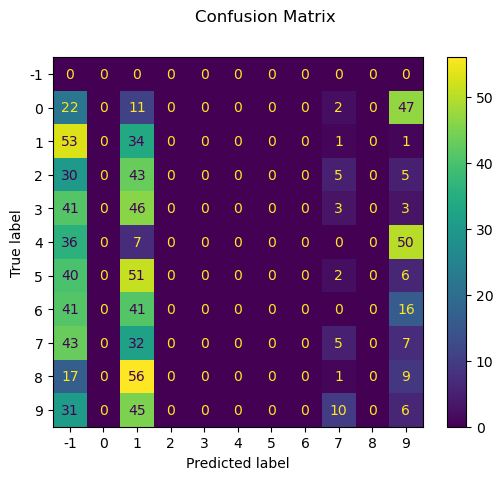

In [119]:
# Confusion matrix
real_labels, pred_labels = zip(*predictions)
disp = sklearn.metrics.ConfusionMatrixDisplay.from_predictions(real_labels, pred_labels)
disp.figure_.suptitle("Confusion Matrix")
plt.show()

In [ ]:
# Classification report
b_test, b_pred = zip(*binary_predictions)
b_test = np.array(b_test)
b_pred = np.array(b_pred)
print(sklearn.metrics.classification_report(b_test, b_pred))

              precision    recall  f1-score   support

           0       0.15      1.00      0.25        82
           1       1.00      0.04      0.09        89
           2       0.79      0.67      0.73        83
           3       0.53      0.75      0.62        93
           4       1.00      0.14      0.25        93
           5       1.00      0.22      0.36        99
           6       0.89      0.66      0.76        98
           7       0.68      0.92      0.78        87
           8       0.34      0.49      0.40        83
           9       0.00      0.00      0.00        92

   micro avg       0.39      0.48      0.43       899
   macro avg       0.64      0.49      0.42       899
weighted avg       0.65      0.48      0.42       899
 samples avg       0.40      0.48      0.43       899



/home/xxz/miniforge3/envs/superneuroabm/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/xxz/miniforge3/envs/superneuroabm/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


: 

: 

: 